# Global Superstore Profitability Analysis

## 1. Project Background

Global Superstore is a multinational retail company operating across multiple markets worldwide.

This project analyzes sales transactions from 2014 to 2017 to evaluate business performance across products, categories, and markets.

The objective is to identify key profitability drivers, uncover business opportunities, and provide actionable recommendations to support better decision-making.

## 2. Business Objective

This project aims to evaluate the overall business performance of Global Superstore between 2014 and 2017 through data analysis.

The analysis focuses on the following business questions:

- How did sales, profit, and profit margin change over time?
- Which product categories generated the highest profitability?
- Which markets contributed the most to overall profit?
- What business factors may have contributed to the decline in profitability?

The findings will support data-driven business decisions and provide practical recommendations for improving future business performance.

## 3. Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 4. Load Dataset

This project uses the cleaned Global Superstore dataset prepared during the SQL analysis phase.

The dataset contains order-level information including sales, profit, product category, customer, region, market, discount, and return status.

The data is loaded into a pandas DataFrame for further exploration and visualization.

In [3]:
df = pd.read_csv("orders_analysis_base.csv")
df.head()
df.shape

(51290, 34)

## 5. Data Cleaning

The dataset has already been cleaned and prepared in SQL.

This step performs a final data quality check to verify:

- Dataset structure
- Missing values
- Duplicate records
- Data types

No additional cleaning is required before analysis.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   row_id               51290 non-null  int64  
 1   order_id             51290 non-null  object 
 2   order_date           51290 non-null  object 
 3   ship_date            51290 non-null  object 
 4   ship_mode            51290 non-null  object 
 5   customer_id          51290 non-null  object 
 6   customer_name        51290 non-null  object 
 7   segment              51290 non-null  object 
 8   postal_code          9994 non-null   float64
 9   city                 51290 non-null  object 
 10  state                51290 non-null  object 
 11  country              51290 non-null  object 
 12  region               51290 non-null  object 
 13  market               51290 non-null  object 
 14  product_id           51290 non-null  object 
 15  product_name         51290 non-null 

In [5]:
df.isnull().sum()

row_id                     0
order_id                   0
order_date                 0
ship_date                  0
ship_mode                  0
customer_id                0
customer_name              0
segment                    0
postal_code            41296
city                       0
state                      0
country                    0
region                     0
market                     0
product_id                 0
product_name               0
sub_category               0
category                   0
sales                      0
quantity                   0
discount                   0
profit                     0
shipping_cost              0
order_priority             0
is_returned                0
return_status              0
order_year                 0
order_month                0
order_quarter              0
order_year_month           0
profit_margin              0
unit_price                 0
shipping_cost_ratio        0
is_loss_line               0
dtype: int64

In [6]:
df.duplicated().sum()

0

No duplicate records were found.

In [7]:
df.describe()

,row_id,postal_code,sales,quantity,discount,profit,shipping_cost,is_returned,order_year,order_month,order_quarter,profit_margin,unit_price,shipping_cost_ratio,is_loss_line
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490685,3.476545,0.142883,28.610968,26.478664,0.112147,2015.777208,7.516027,2.792338,0.047428,71.657518,0.122982,0.244492
std,14806.29199,32063.693350,487.565388,2.278766,0.212285,174.341067,57.251368,0.315550,1.098931,3.300526,1.066536,0.465672,113.581519,0.086233,0.429790
min,1.00000,1040.000000,0.440000,1.000000,0.000000,-6599.980000,1.000000,0.000000,2014.000000,1.000000,1.000000,-4.733637,0.335000,0.000409,0.000000
25%,12823.25000,23223.000000,30.762500,2.000000,0.000000,0.000000,2.610000,0.000000,2015.000000,5.000000,2.000000,0.000000,11.800000,0.068296,0.000000
50%,25645.50000,56430.500000,85.055000,3.000000,0.000000,9.240000,7.790000,0.000000,2016.000000,8.000000,3.000000,0.169177,29.400000,0.099161,0.000000
75%,38467.75000,90008.000000,251.055000,5.000000,0.200000,36.810000,24.450000,0.000000,2017.000000,10.000000,4.000000,0.333145,82.160000,0.152114,0.000000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.980000,933.570000,1.000000,2017.000000,12.000000,4.000000,0.500220,3773.080000,2.295455,1.000000


### Data Cleaning Summary

The dataset is generally clean.

Only the `postal_code` field contains missing values because postal codes are unavailable for many international regions.

Since postal code is not required for this profitability analysis, no further cleaning is necessary.

## 6. Exploratory Data Analysis(EDA)

### 6.1 Dataset Overview

This section provides a high-level overview of the dataset by calculating the key business metrics.

The purpose is to understand the overall sales performance before performing detailed analysis.

In [8]:
# Overall Business Metrics

total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
profit_margin = total_profit / total_sales
total_orders = df["order_id"].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2%}")
print(f"Total Orders: {total_orders:,}")

Total Sales: $12,642,507.25
Total Profit: $1,467,456.55
Profit Margin: 11.61%
Total Orders: 25,728


### 6.2 Sales Trend Analysis

To understand the company's overall business growth, annual sales are analyzed to identify long-term revenue trends.

The results provide an overview of sales performance between 2014 and 2017.

In [9]:
# Annual Sales Trend

sales_trend = (
    df.groupby("order_year")["sales"]
      .sum()
      .reset_index()
)

sales_trend

,order_year,sales
0,2014,2259451.64
1,2015,2677439.91
2,2016,3405748.03
3,2017,4299867.67


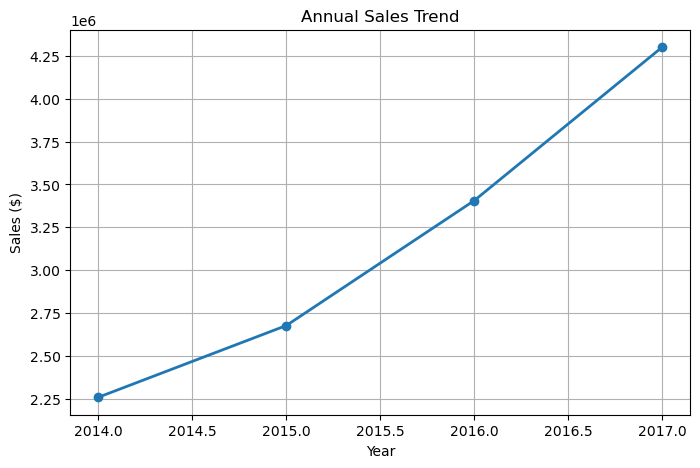

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    sales_trend["order_year"],
    sales_trend["sales"],
    marker="o",
    linewidth=2
)

plt.title("Annual Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.grid(True)

plt.show()

### 6.3 Profit Trend Analysis

Annual profit is analyzed to evaluate whether profitability improved consistently with sales growth.

Comparing sales and profit trends helps determine whether revenue growth translated into sustainable business performance.

In [11]:
# Annual Profit Trend

profit_trend = (
    df.groupby("order_year")["profit"]
      .sum()
      .reset_index()
)

profit_trend

,order_year,profit
0,2014,248940.41
1,2015,307415.30
2,2016,406934.84
3,2017,504166.00


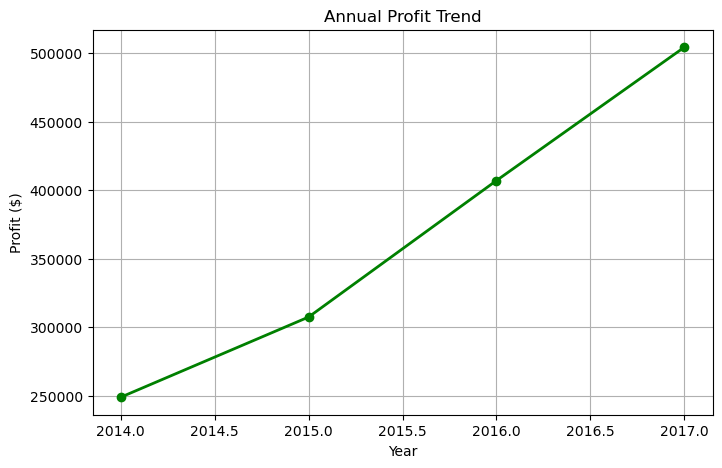

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    profit_trend["order_year"],
    profit_trend["profit"],
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Annual Profit Trend")
plt.xlabel("Year")
plt.ylabel("Profit ($)")
plt.grid(True)

plt.show()

### 6.4 Profit Margin Trend

Profit margin is calculated annually to evaluate the quality of business growth.

Unlike sales or profit alone, profit margin reflects how efficiently revenue is converted into profit over time.

In [14]:
margin_trend = (
    df.groupby("order_year")
      .agg(
          total_sales=("sales","sum"),
          total_profit=("profit","sum")
      )
      .reset_index()
)

margin_trend["profit_margin"] = (
    margin_trend["total_profit"]
    /
    margin_trend["total_sales"]
)

In [15]:
margin_trend

,order_year,total_sales,total_profit,profit_margin
0,2014,2259451.64,248940.41,0.110177
1,2015,2677439.91,307415.30,0.114817
2,2016,3405748.03,406934.84,0.119485
3,2017,4299867.67,504166.00,0.117252


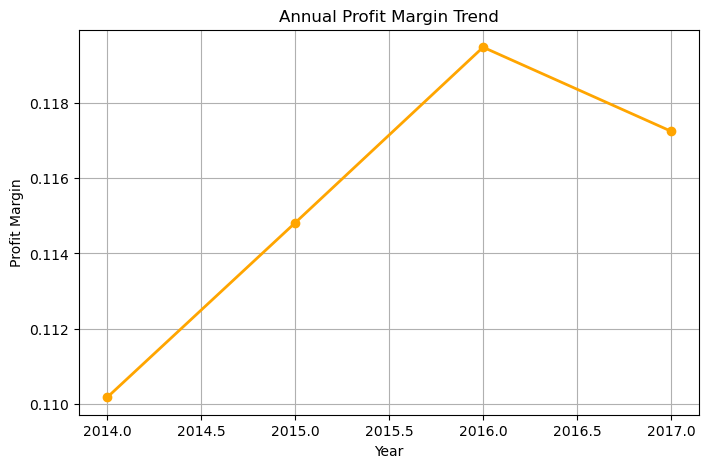

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    margin_trend["order_year"],
    margin_trend["profit_margin"],
    marker="o",
    linewidth=2,
    color="orange"
)

plt.title("Annual Profit Margin Trend")
plt.xlabel("Year")
plt.ylabel("Profit Margin")

plt.grid(True)

plt.show()

### 6.5 Category Performance

This analysis compares total profit across product categories to identify which business segments contribute most to overall profitability.

Understanding category performance helps prioritize future business investments.

In [17]:
category_profit = (
    df.groupby("category")["profit"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_profit

,category,profit
0,Technology,663779.25
1,Office Supplies,518594.72
2,Furniture,285082.58


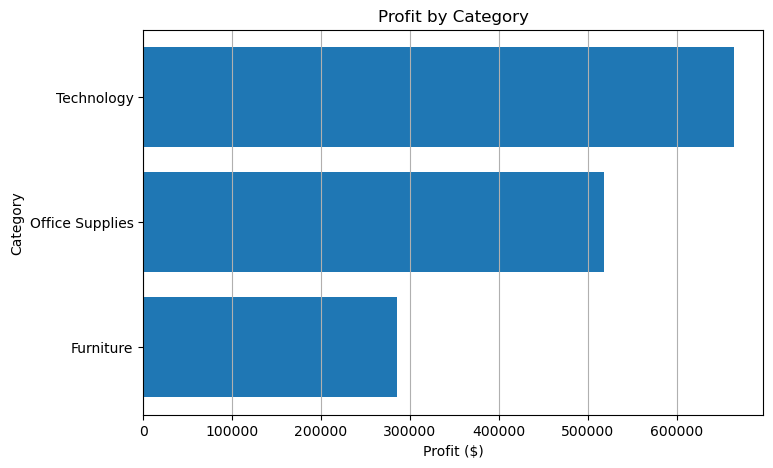

In [18]:
plt.figure(figsize=(8,5))

plt.barh(
    category_profit["category"],
    category_profit["profit"]
)

plt.title("Profit by Category")
plt.xlabel("Profit ($)")
plt.ylabel("Category")

plt.grid(axis="x")

plt.gca().invert_yaxis()

plt.show()

### 6.6 Market Performance

Profit is analyzed across global markets to compare regional business performance.

This helps identify the strongest and weakest geographic markets.

In [19]:
market_profit = (
    df.groupby("market")["profit"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

market_profit

,market,profit
0,Europe,449550.64
1,Asia Pacific,403175.96
2,USCA,304215.18
3,LATAM,221643.64
4,Africa,88871.13


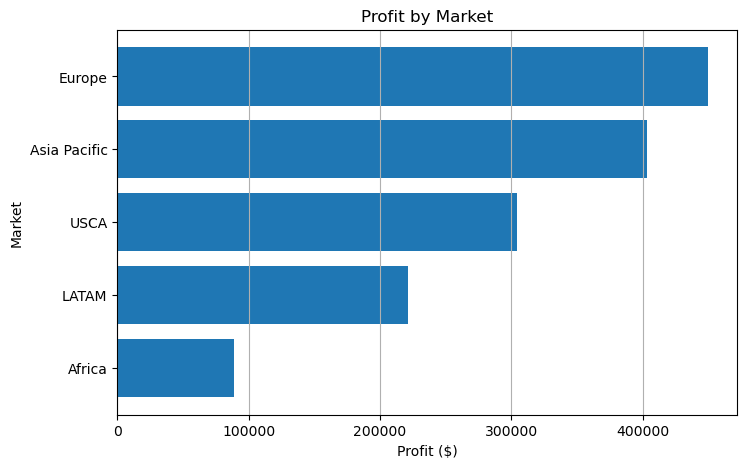

In [20]:
plt.figure(figsize=(8,5))

plt.barh(
    market_profit["market"],
    market_profit["profit"]
)

plt.title("Profit by Market")
plt.xlabel("Profit ($)")
plt.ylabel("Market")

plt.grid(axis="x")

plt.gca().invert_yaxis()

plt.show()

### 6.7 Discount Analysis

This section examines the overall discount strategy by analyzing the average discount level across years.

The objective is to determine whether increasing discounts contributed to changes in profitability.

In [21]:
discount_trend = (
    df.groupby("order_year")["discount"]
      .mean()
      .reset_index()
)

discount_trend

,order_year,discount
0,2014,0.148163
1,2015,0.141262
2,2016,0.140239
3,2017,0.143268


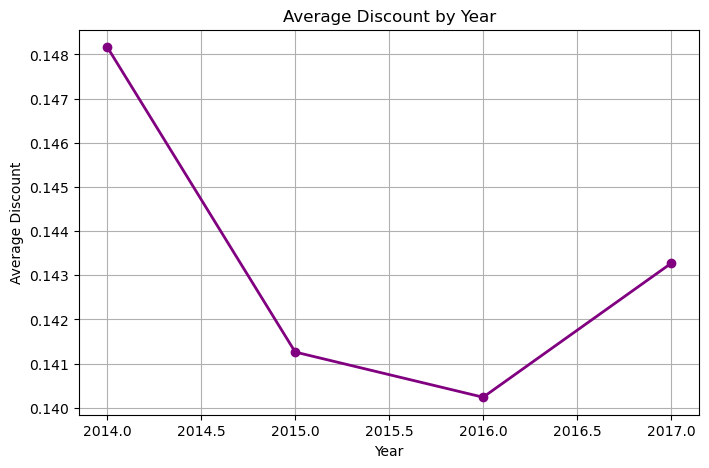

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    discount_trend["order_year"],
    discount_trend["discount"],
    marker="o",
    linewidth=2,
    color="purple"
)

plt.title("Average Discount by Year")
plt.xlabel("Year")
plt.ylabel("Average Discount")

plt.grid(True)

plt.show()

### Observation

Although the average discount fluctuated slightly across years, it remained around 14% throughout the analysis period.

This indicates that the company's overall discount strategy remained relatively consistent.

Therefore, declining profitability is unlikely to be explained solely by changes in the average discount level.

Further analysis is required to investigate whether specific high-discount transactions had a disproportionate impact on profitability.

### 6.8 Discount Band Analysis

To better understand the impact of discount strategies, transactions are divided into three discount bands:

- No Discount (0%)
- Low Discount (0% < Discount < 20%)
- High Discount (≥20%)

Profitability is then compared across these groups to identify whether heavy discounting contributes to declining margins.

In [28]:
# Create Discount Band

conditions = [
    df["discount"].eq(0),
    df["discount"].gt(0) & df["discount"].lt(0.2),
    df["discount"].ge(0.2)
]

labels = [
    "No Discount",
    "Low Discount",
    "High Discount"
]

df["discount_band"] = np.select(
    conditions,
    labels,
    default="Unknown"
)

df[["discount", "discount_band"]].head()

,discount,discount_band
0,0.0,No Discount
1,0.0,No Discount
2,0.0,No Discount
3,0.0,No Discount
4,0.0,No Discount


In [29]:
df["discount_band"].value_counts()

discount_band
No Discount      29470
High Discount    16326
Low Discount      5494
Name: count, dtype: int64

In [30]:
df.loc[
    df["discount"] > 0,
    ["discount", "discount_band"]
].head(10)

,discount,discount_band
389,0.4,High Discount
390,0.4,High Discount
391,0.4,High Discount
392,0.4,High Discount
393,0.4,High Discount
394,0.4,High Discount
395,0.4,High Discount
396,0.4,High Discount
397,0.4,High Discount
398,0.7,High Discount


In [31]:
df.loc[
    df["discount"] == 0.2,
    ["discount", "discount_band"]
].head()

,discount,discount_band
4488,0.2,High Discount
4524,0.2,High Discount
4572,0.2,High Discount
4574,0.2,High Discount
4575,0.2,High Discount


In [32]:
discount_summary = (
    df.groupby("discount_band")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum"),
          Total_Orders=("order_id", "nunique")
      )
      .reset_index()
)

discount_summary["Profit_Margin"] = (
    discount_summary["Total_Profit"]
    / discount_summary["Total_Sales"]
)

discount_summary

,discount_band,Total_Sales,Total_Profit,Total_Orders,Profit_Margin
0,High Discount,3134046.26,-696968.44,9051,-0.222386
1,Low Discount,2254654.34,335752.78,3502,0.148915
2,No Discount,7253806.65,1828672.21,15716,0.252098


### 6.9 Discount Band Profitability

To further investigate whether discount strategy affected profitability, transactions are grouped into three discount bands:

- No Discount
- Low Discount (0% < Discount < 20%)
- High Discount (≥20%)

Sales, profit, and profit margin are compared across these groups.

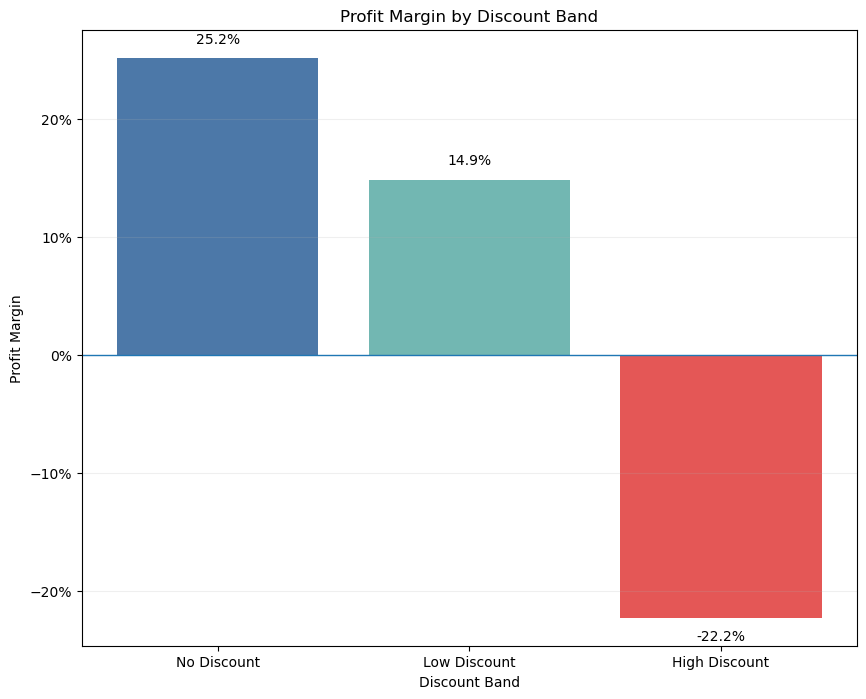

In [38]:
from matplotlib.ticker import PercentFormatter

# Arrange discount bands in a logical order
discount_order = [
    "No Discount",
    "Low Discount",
    "High Discount"
]

discount_plot = (
    discount_summary
    .set_index("discount_band")
    .loc[discount_order]
    .reset_index()
)

plt.figure(figsize=(10, 8))

colors = [
    "#4C78A8",
    "#72B7B2",
    "#E45756"
]

bars = plt.bar(
    discount_plot["discount_band"],
    discount_plot["Profit_Margin"],
    color=colors
)

plt.title("Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin")

# Display the Y-axis as percentages
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

# Add a horizontal reference line at 0%
plt.axhline(0, linewidth=1)

plt.grid(axis="y", alpha=0.2)

# Add percentage labels to each bar
for bar, value in zip(bars, discount_plot["Profit_Margin"]):
    if value >= 0:
        vertical_alignment = "bottom"
        label_y = value + 0.01
    else:
        vertical_alignment = "top"
        label_y = value - 0.01

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f"{value:.1%}",
        ha="center",
        va=vertical_alignment
    )

plt.show()

### Observation

Profit margin declines significantly as discount levels increase.

High-discount transactions generated a negative overall profit margin (-22%), despite contributing substantial sales.

This indicates that aggressive discounting reduced profitability rather than driving sustainable business growth.

### 6.10 High Discount Category Analysis

The previous analysis showed that high-discount transactions generated a negative overall profit margin.

To identify the source of these losses, this section focuses only on transactions with discounts of 20% or higher and compares profitability across product sub-categories.

In [39]:
high_discount_df = df[df["discount"] >= 0.2]

high_discount_df.shape

(16326, 35)

In [40]:
subcategory_profit = (
    high_discount_df
    .groupby("sub_category")
    .agg(
        Total_Sales=("sales", "sum"),
        Total_Profit=("profit", "sum")
    )
    .reset_index()
)

subcategory_profit["Profit_Margin"] = (
    subcategory_profit["Total_Profit"]
    / subcategory_profit["Total_Sales"]
)

subcategory_profit = (
    subcategory_profit
    .sort_values("Total_Profit")
)

subcategory_profit.head(10)

,sub_category,Total_Sales,Total_Profit,Profit_Margin
16,Tables,491751.42,-125325.74,-0.254856
4,Bookcases,326652.13,-84837.38,-0.259718
13,Phones,390813.66,-70036.62,-0.179207
11,Machines,188442.14,-67778.21,-0.359677
14,Storage,205112.53,-66020.14,-0.321873
5,Chairs,556847.66,-61264.29,-0.110020
1,Appliances,138713.42,-52662.36,-0.379649
6,Copiers,229923.51,-42061.82,-0.182938
0,Accessories,141624.93,-29277.72,-0.206727
3,Binders,146520.54,-22298.37,-0.152186


### Visualization

The following chart highlights the product sub-categories generating the largest losses under high-discount transactions.

In [42]:
subcategory_profit["Loss_Amount"] = (
    subcategory_profit["Total_Profit"].abs()
)

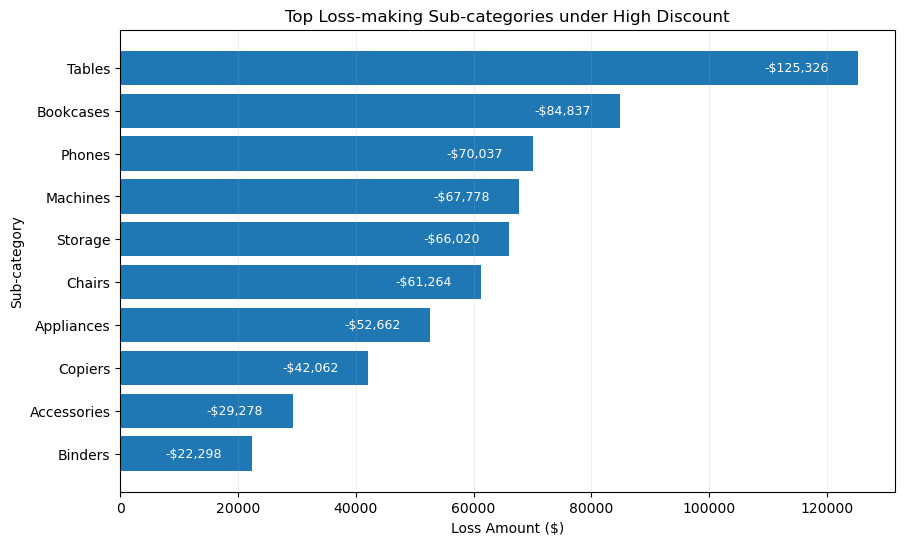

In [48]:
plt.figure(figsize=(10,6))

top_loss = (
    subcategory_profit
    .sort_values("Loss_Amount", ascending=False)
    .head(10)
)

bars = plt.barh(
    top_loss["sub_category"],
    top_loss["Loss_Amount"]
)
plt.title(
    "Top Loss-making Sub-categories under High Discount"
)
plt.xlabel("Loss Amount ($)")
plt.ylabel("Sub-category")

plt.grid(axis="x", alpha=0.2)

# Add value labels
for bar in bars:
    value = abs(bar.get_width())

    plt.text(
        value - 5000,
        bar.get_y() + bar.get_height()/2,
        f"-${value:,.0f}",
        va="center",
        ha="right",
        fontsize=9,
        color="white"
    )

plt.gca().invert_yaxis()

plt.show()

### Observation

Tables generated the largest loss under high-discount transactions, followed by Bookcases, Phones, Machines, and Storage.

These product sub-categories consistently produced negative profits despite generating substantial sales, suggesting that aggressive discounting significantly eroded profitability.

This indicates that discount optimization should prioritize these high-risk product categories rather than applying uniform discount strategies across all products.

### 6.10 High-discount Market Analysis

To identify where discount-related losses are concentrated, the analysis focuses on transactions with discounts greater than or equal to 20%.

Sales, profit, and profit margin are summarized by market to determine which regions contribute most to profitability deterioration.

In [49]:
high_discount_df = df[df["discount"] >= 0.2]

high_discount_df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,postal_code,city,...,return_status,order_year,order_month,order_quarter,order_year_month,profit_margin,unit_price,shipping_cost_ratio,is_loss_line,discount_band
389,4817,US-2014-JH161805-41994,2014-12-21,2014-12-23,First Class,JH-161805,Justin Hirsh,Consumer,NaN,Buenos Aires,...,Not Returned,2014,12,4,2014-12,0.016604,255.624444,0.167781,0,High Discount
390,6915,US-2017-BT115305-43067,2017-11-28,2017-12-03,Standard Class,BT-115305,Bradley Talbott,Home Office,NaN,Buenos Aires,...,Not Returned,2017,11,4,2017-11,-0.000063,255.564000,0.101071,1,High Discount
391,6755,US-2017-BW112005-42919,2017-07-03,2017-07-05,Second Class,BW-112005,Ben Wallace,Consumer,NaN,Buenos Aires,...,Not Returned,2017,7,3,2017-07,-0.003433,141.892857,0.110385,1,High Discount
392,6986,MX-2015-CR127305-42250,2015-09-03,2015-09-06,First Class,CR-127305,Craig Reiter,Consumer,NaN,Buenos Aires,...,Not Returned,2015,9,3,2015-09,-0.070560,57.540000,0.301066,1,High Discount
393,8221,MX-2015-JH159855-42283,2015-10-06,2015-10-07,Same Day,JH-159855,Joseph Holt,Consumer,NaN,Buenos Aires,...,Not Returned,2015,10,4,2015-10,-0.137306,59.298000,0.340416,1,High Discount


In [50]:
market_profit = (
    high_discount_df
    .groupby("market")
    .agg(
        Total_Sales=("sales", "sum"),
        Total_Profit=("profit", "sum")
    )
    .reset_index()
)

In [51]:
market_profit["Profit_Margin"] = (
    market_profit["Total_Profit"]
    / market_profit["Total_Sales"]
)

In [52]:
market_profit = (
    market_profit
    .sort_values("Total_Profit")
)

market_profit

,market,Total_Sales,Total_Profit,Profit_Margin
1,Asia Pacific,837313.95,-269859.88,-0.322292
2,Europe,403625.78,-171505.96,-0.424913
3,LATAM,706004.26,-121958.24,-0.172744
0,Africa,59737.56,-88606.08,-1.483256
4,USCA,1127364.71,-45038.28,-0.039950


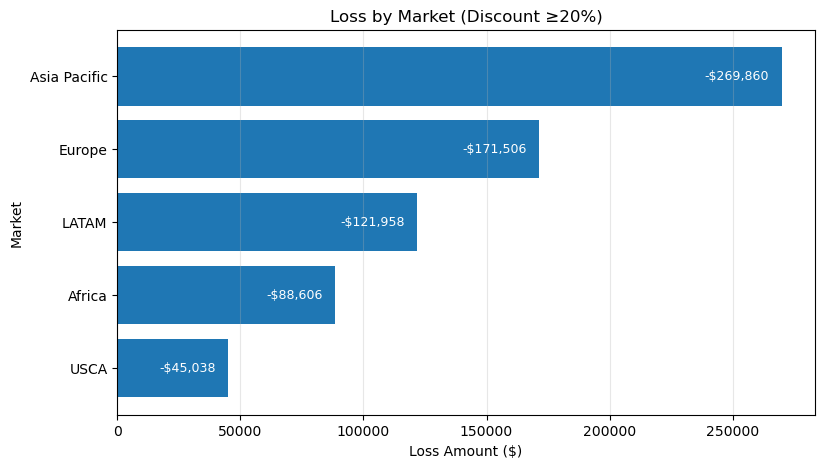

In [59]:
### # Calculate absolute loss amount
market_profit["Loss_Amount"] = market_profit["Total_Profit"].abs()

# Sort markets from largest to smallest loss
market_loss = (
    market_profit
    .sort_values("Loss_Amount", ascending=False)
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    market_loss["market"],
    market_loss["Loss_Amount"]
)

plt.title("Loss by Market (Discount ≥20%)")
plt.xlabel("Loss Amount ($)")
plt.ylabel("Market")
plt.grid(axis="x", alpha=0.3)

# Add value labels before plt.show()
for bar in bars:
    value = bar.get_width()

    plt.text(
        value - 5000,
        bar.get_y() + bar.get_height() / 2,
        f"-${value:,.0f}",
        va="center",
        ha="right",
        fontsize=9,
        color="white"
    )

# Put the largest-loss market at the top
plt.gca().invert_yaxis()

plt.show()

### Observation

High-discount losses are concentrated in the Asia Pacific and Europe markets.

Asia Pacific generated the largest absolute loss under high-discount transactions, while Europe recorded the lowest profit margin among all markets.

This indicates that discount strategies should be reviewed and optimized differently across markets rather than applying a uniform pricing policy.

### 6.11 Return Analysis

To determine whether discounting also increases return risk, the analysis is performed at the order level.

Each order is classified into:

- High Discount Order
- Non-high Discount Order

The return rate of these two groups is then compared.

In [60]:
order_summary = (
    df.groupby("order_id")
      .agg(
          Order_Sales=("sales", "sum"),
          Order_Profit=("profit", "sum"),
          Returned=("is_returned", "max"),
          High_Discount_Order=("discount", lambda x: (x >= 0.2).any())
      )
      .reset_index()
)

order_summary.head()

,order_id,Order_Sales,Order_Profit,Returned,High_Discount_Order
0,AE-2014-PO8865138-41914,161.08,-246.08,0,True
1,AE-2016-EB4110138-42657,229.00,-236.96,0,True
2,AE-2016-MY7380138-42735,23.64,-38.07,0,True
3,AE-2017-GH4665138-43082,281.51,-429.10,1,True
4,AE-2017-JD5790138-42801,6.43,-11.57,0,True


6.11.1 Return Rate Comparison

In [62]:
return_summary = (
    order_summary.groupby("High_Discount_Order")
    .agg(
        Total_Orders=("order_id", "count"),
        Returned_Orders=("Returned", "sum")
    )
    .reset_index()
)

return_summary["Return_Rate"] = (
    return_summary["Returned_Orders"]
    / return_summary["Total_Orders"]
)

return_summary

,High_Discount_Order,Total_Orders,Returned_Orders,Return_Rate
0,False,16677,1163,0.069737
1,True,9051,807,0.089161


#### Observation

High-discount orders show a noticeably higher return rate than non-high-discount orders.

Return Rate

- High Discount Orders: **8.9%**
- Non-high Discount Orders: **7.0%**

This suggests that aggressive discounting is associated with increased return risk, further reducing overall profitability.

6.11.2 Order-level Profit Analysis

In [63]:
order_analysis = (
    order_summary.groupby(
        ["High_Discount_Order", "Returned"]
    )
    .agg(
        Total_Orders=("order_id", "count"),
        Total_Sales=("Order_Sales", "sum"),
        Total_Profit=("Order_Profit", "sum")
    )
    .reset_index()
)

order_analysis["Profit_Margin"] = (
    order_analysis["Total_Profit"]
    / order_analysis["Total_Sales"]
)

order_analysis

,High_Discount_Order,Returned,Total_Orders,Total_Sales,Total_Profit,Profit_Margin
0,False,0,15514,7824273.63,1803906.15,0.230553
1,False,1,1163,849241.95,195450.81,0.230147
2,True,0,8244,3460789.75,-473046.00,-0.136687
3,True,1,807,508201.92,-58854.41,-0.115809


6.11.3 Visualize Order-level Profit Margin

#### Observation

The comparison confirms that high-discount orders remain unprofitable regardless of whether they are returned.

Key findings:

- Normal orders maintain a healthy profit margin of approximately **23%**.
- High-discount orders generate negative profit margins even when customers keep the products.
- Returned high-discount orders further reduce profitability, but returns are not the primary cause of losses.

This indicates that the current high-discount pricing strategy is fundamentally unsustainable rather than being driven solely by product returns.

# 7. Key Business Insights

Based on the profitability analysis, the following key business insights were identified:

### 1. Sales continued to grow, but profitability stagnated.

Although annual sales increased steadily from 2014 to 2017, profit margin stopped improving after 2016, suggesting that revenue growth was not fully translated into profit growth.

---

### 2. Overall discount levels remained relatively stable.

The average discount did not change significantly over the four-year period. Therefore, declining profitability cannot be explained by an overall increase in discounting.

---

### 3. High-discount transactions were the primary driver of losses.

Orders with discounts of 20% or above generated a negative overall profit margin, indicating that aggressive discounting substantially eroded profitability.

---

### 4. Losses were concentrated in a limited number of product categories.

Tables, Bookcases, Phones, Machines and Storage accounted for a disproportionate share of total losses under high-discount conditions.

---

### 5. Asia Pacific experienced the largest losses under high-discount strategies.

Regional analysis indicates that profitability deterioration was particularly severe in the Asia Pacific market, suggesting that discount policies should be optimized by region rather than applied uniformly.

---

### 6. High-discount orders also showed higher return rates.

Orders with discounts of 20% or above were returned more frequently than normal orders, further reducing overall profitability.

---

### 7. High-discount orders remained unprofitable even without returns.

Order-level analysis confirmed that aggressive discounting itself was the fundamental cause of profit deterioration. Product returns amplified losses but were not the primary driver.

# 8. Business Recommendations

Based on the findings above, the following recommendations are proposed:

### Optimize discount policies

Avoid applying discounts above 20% across all products. Instead, implement category-specific and region-specific pricing strategies.

---

### Focus on high-loss product categories

Review pricing strategies for Tables, Bookcases, Machines, Storage and Phones to improve profitability before pursuing additional sales growth.

---

### Improve regional pricing management

Given the significant losses observed in the Asia Pacific market, discount strategies should be reviewed separately for each market rather than using a global discount policy.

---

### Balance revenue growth with profitability

Sales growth should not be evaluated independently. Future performance management should incorporate both revenue and profit margin as key business metrics.

---

### Monitor return risk for promotional campaigns

High-discount promotions should be accompanied by return-rate monitoring to reduce unnecessary operational losses.